# Circular cone-beam X-ray transform: microlocal artifact reduction

Ongoing numerical study of streak artifacts from a circular source trajectory. A synthetic 3-D phantom provides a comparison between an elliptic local reconstruction and a microlocally modified operator. The experiment includes a direct numerical reference, reconstruction slices, and an artifact diagnostic.

## 1. Problem setup and operators

The object $f$ is supported in $[-1,1]^3$, with source trajectory
$$a(t)=R(\cos t,\sin t,0),\qquad R=2,\quad 0\leq t<2\pi.$$
The divergent X-ray transform and back-projection, with data measure $dt\,d\theta$, are
$$
(R_Cf)(t,\theta)=\int_0^\infty f(a(t)+s\theta)\,ds,\qquad \theta\in S^2,
$$
$$
(R_C^*g)(x)=\int_0^{2\pi}
\frac{g\!\left(t,\frac{x-a(t)}{|x-a(t)|}\right)}{|x-a(t)|^2}\,dt.
$$
Thus $Bf=R_C^*R_Cf$ is the normal operator. This uses the source-curve back-projection weight in [Finch, Lan and Uhlmann (2003), §8](https://library.slmath.org/books/Book47/files/uhlmann.pdf), with inward half-rays and the angular parameter $t$.

For $\xi_h=(\xi_1,\xi_2)$, the conditions $(x-a(t))\cdot\xi=0$ and $a'(t)\cdot\xi=0$ give the two characteristic sheets
$$p_\pm(x,\xi)=x\cdot\xi\mp R|\xi_h|=0.$$
Their product defines
$$p_2(x,\xi)=(x\cdot\xi)^2-R^2(\xi_1^2+\xi_2^2).$$
With $D_j=-i\partial_{x_j}$, the implemented operator has coefficients to the left of the derivatives:
$$P_2(x,D)=\sum_{i,j=1}^3 x_i x_j D_iD_j-R^2(D_1^2+D_2^2).$$
For the Fourier multiplier $\Lambda_\mu$ with symbol $(\mu^2+|\xi|^2)^{1/2}$, $\mu=\pi$, the comparison is
$$L_{\mathrm{standard}}f=\Lambda_\mu Bf,\qquad
L_{\mathrm{modified}}f=\Lambda_\mu^{-1}P_2(x,D)Bf.$$
Both filters have order $+1$. The vanishing of $p_2$ on the characteristic sheets motivates the modified filter; the calculations below assess its effect for a finite discretization.

## 2. Discretization

Volumes use `float32` arrays in `[z, y, x]` order. The source angles exclude the repeated endpoint $2\pi$. Projection uses midpoint ray integration with trilinear interpolation and zero extension; back-projection uses interpolation on a rotating flat detector through the origin. This discretizes the continuous back-projection rather than the exact matrix transpose of the discrete projector.

The filter uses signed FFT frequencies and periodic Fourier differentiation. The original MATLAB driver calls `Psi(C,-1)` without supplying `Psi.m`; here the smoothing is explicitly $\Lambda_\mu^{-1}$. MATLAB files and external datasets are unnecessary for execution. Source attribution is recorded in [THIRD_PARTY_NOTICES.md](THIRD_PARTY_NOTICES.md).

## 3. Environment and phantom

Python 3.11; dependencies are pinned in `requirements.txt`. A fresh kernel followed by sequential execution reproduces the experiment. The modified Shepp–Logan phantom is generated from ten ellipsoids.

In [1]:
from __future__ import annotations

from time import perf_counter
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path
import json
import os
import platform

import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
from scipy import fft as sp_fft
from scipy.ndimage import binary_dilation, map_coordinates, sobel


# Phantom adapted from phantom3d.m: Copyright 2005 Matthias Christian Schabel.
# Original GPL notice and adaptation details: THIRD_PARTY_NOTICES.md.
ELLIPSOIDS = np.array(
    [
        [1.0, 0.6900, 0.920, 0.810, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [-0.8, 0.6624, 0.874, 0.780, 0.0, -0.0184, 0.0, 0.0, 0.0, 0.0],
        [-0.2, 0.1100, 0.310, 0.220, 0.22, 0.0, 0.0, -18.0, 0.0, 10.0],
        [-0.2, 0.1600, 0.410, 0.280, -0.22, 0.0, 0.0, 18.0, 0.0, 10.0],
        [0.1, 0.2100, 0.250, 0.410, 0.0, 0.35, -0.15, 0.0, 0.0, 0.0],
        [0.1, 0.0460, 0.046, 0.050, 0.0, 0.1, 0.25, 0.0, 0.0, 0.0],
        [0.1, 0.0460, 0.046, 0.050, 0.0, -0.1, 0.25, 0.0, 0.0, 0.0],
        [0.1, 0.0460, 0.023, 0.050, -0.08, -0.605, 0.0, 0.0, 0.0, 0.0],
        [0.1, 0.0230, 0.023, 0.020, 0.0, -0.606, 0.0, 0.0, 0.0, 0.0],
        [0.1, 0.0230, 0.046, 0.020, 0.06, -0.605, 0.0, 0.0, 0.0, 0.0],
    ],
    dtype=np.float64,
)


def phantom3d(n: int, ellipsoids: np.ndarray = ELLIPSOIDS) -> np.ndarray:
    """Modified 3-D Shepp-Logan phantom, stored as [z,y,x]."""
    grid = np.linspace(-1.0, 1.0, n, dtype=np.float32)
    z, y, x = np.meshgrid(grid, grid, grid, indexing="ij", sparse=True)
    out = np.zeros((n, n, n), dtype=np.float32)
    for amplitude, a, b, c, x0, y0, z0, phi, theta, psi in ellipsoids:
        phi, theta, psi = np.deg2rad([phi, theta, psi])
        cphi, sphi = np.cos(phi), np.sin(phi)
        ctheta, stheta = np.cos(theta), np.sin(theta)
        cpsi, spsi = np.cos(psi), np.sin(psi)
        rot = np.array(
            [
                [cpsi * cphi - ctheta * sphi * spsi,
                 cpsi * sphi + ctheta * cphi * spsi,
                 spsi * stheta],
                [-spsi * cphi - ctheta * sphi * cpsi,
                 -spsi * sphi + ctheta * cphi * cpsi,
                 cpsi * stheta],
                [stheta * sphi, -stheta * cphi, ctheta],
            ]
        )
        xp = rot[0, 0] * x + rot[0, 1] * y + rot[0, 2] * z
        yp = rot[1, 0] * x + rot[1, 1] * y + rot[1, 2] * z
        zp = rot[2, 0] * x + rot[2, 1] * y + rot[2, 2] * z
        inside = ((xp - x0) / a) ** 2 + ((yp - y0) / b) ** 2 + ((zp - z0) / c) ** 2 <= 1.0
        out[inside] += np.float32(amplitude)
    return out



plt.rcParams.update({'figure.dpi': 120, 'image.cmap': 'gray'})

## 4. Detector-based normal operator

With detector width proportional to $N$ and $O(N)$ samples per ray, the forward/back-projection costs $O(n_tN^3)$. Threaded angle groups accumulate partial volumes; storage includes $O(wN^3+n_tN^2)$ arrays for $w$ workers, plus ray-integration temporaries.

In [2]:
def _ray_box_intersections(source: np.ndarray, directions: np.ndarray, half_width: float = 1.0):
    tiny = 1e-12
    safe = np.where(np.abs(directions) > tiny, directions, np.where(directions >= 0, tiny, -tiny))
    t0 = (-half_width - source[None, :]) / safe
    t1 = (half_width - source[None, :]) / safe
    enter = np.maximum(0.0, np.max(np.minimum(t0, t1), axis=1))
    leave = np.min(np.maximum(t0, t1), axis=1)
    valid = leave > enter
    return enter, leave, valid


def _project_one_angle(
    volume: np.ndarray,
    angle: float,
    detector_coordinates: np.ndarray,
    source_radius: float,
    sample_step: float,
    ray_chunk: int,
) -> np.ndarray:
    n = volume.shape[0]
    c, s = np.cos(angle), np.sin(angle)
    source = np.array([source_radius * c, source_radius * s, 0.0], dtype=np.float64)
    u_axis = np.array([-s, c, 0.0], dtype=np.float64)
    u, v = np.meshgrid(detector_coordinates, detector_coordinates, indexing="xy")
    detector_points = u.ravel()[:, None] * u_axis[None, :]
    detector_points[:, 2] = v.ravel()
    directions = detector_points - source[None, :]
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    enter, leave, valid = _ray_box_intersections(source, directions)
    valid_indices = np.flatnonzero(valid)
    projection = np.zeros(directions.shape[0], dtype=np.float32)
    scale = (n - 1) / 2.0

    for first in range(0, valid_indices.size, ray_chunk):
        idx = valid_indices[first:first + ray_chunk]
        ray_lengths = leave[idx] - enter[idx]
        n_steps = np.maximum(1, np.ceil(ray_lengths / sample_step).astype(np.int32))
        max_steps = int(n_steps.max())
        step = ray_lengths / n_steps
        k = np.arange(max_steps, dtype=np.float32)[None, :]
        sample_distance = enter[idx, None] + (k + 0.5) * step[:, None]
        mask = k < n_steps[:, None]
        points = source[None, None, :] + sample_distance[:, :, None] * directions[idx, None, :]
        coords = np.empty((3, points.shape[0] * points.shape[1]), dtype=np.float32)
        coords[0] = ((points[:, :, 2] + 1.0) * scale).ravel()
        coords[1] = ((points[:, :, 1] + 1.0) * scale).ravel()
        coords[2] = ((points[:, :, 0] + 1.0) * scale).ravel()
        values = map_coordinates(
            volume,
            coords,
            order=1,
            mode="constant",
            cval=0.0,
            prefilter=False,
        ).reshape(points.shape[:2])
        values *= mask
        projection[idx] = np.sum(values, axis=1) * step
    return projection.reshape(u.shape)


def cone_beam_project(
    volume: np.ndarray,
    angles: np.ndarray,
    *,
    source_radius: float = 2.0,
    detector_pixels: int | None = None,
    detector_half_width: float = 2.05,
    samples_per_voxel: float = 1.0,
    ray_chunk: int = 4096,
    workers: int = 1,
) -> tuple[np.ndarray, np.ndarray]:
    """Flat-panel cone-beam projection for a circular source orbit.

    The detector plane passes through the origin and rotates with the source.
    Projection values are physical-arclength integrals along rays.
    """
    volume = np.asarray(volume, dtype=np.float32, order="C")
    if volume.ndim != 3 or len(set(volume.shape)) != 1:
        raise ValueError("volume must be a cubic 3-D array")
    n = volume.shape[0]
    detector_pixels = int(detector_pixels or 2 * n)
    detector_coordinates = np.linspace(
        -detector_half_width, detector_half_width, detector_pixels, dtype=np.float32
    )
    sample_step = (2.0 / (n - 1)) / samples_per_voxel

    if workers == 1:
        projections = [
            _project_one_angle(
                volume, float(angle), detector_coordinates, source_radius, sample_step, ray_chunk
            )
            for angle in angles
        ]
    else:
        from joblib import Parallel, delayed

        projections = Parallel(n_jobs=workers, prefer="threads")(
            delayed(_project_one_angle)(
                volume, float(angle), detector_coordinates, source_radius, sample_step, ray_chunk
            )
            for angle in angles
        )
    return np.stack(projections), detector_coordinates


def _backproject_one_angle(
    projection: np.ndarray,
    angle: float,
    detector_coordinates: np.ndarray,
    n: int,
    source_radius: float,
    z_chunk: int,
) -> np.ndarray:
    grid = np.linspace(-1.0, 1.0, n, dtype=np.float32)
    y, x = np.meshgrid(grid, grid, indexing="ij")
    c, s = np.cos(angle), np.sin(angle)
    radial = c * x + s * y
    tangent = -s * x + c * y
    lam = source_radius / (source_radius - radial)
    u = lam * tangent
    distance_xy_squared = (x - source_radius * c) ** 2 + (y - source_radius * s) ** 2
    detector_min = float(detector_coordinates[0])
    detector_step = float(detector_coordinates[1] - detector_coordinates[0])
    u_index = (u - detector_min) / detector_step
    out = np.zeros((n, n, n), dtype=np.float32)

    for first_z in range(0, n, z_chunk):
        z_values = grid[first_z:first_z + z_chunk, None, None]
        v = lam[None, :, :] * z_values
        v_index = (v - detector_min) / detector_step
        u_broadcast = np.broadcast_to(u_index, v_index.shape)
        samples = map_coordinates(
            projection,
            np.stack((v_index, u_broadcast)),
            order=1,
            mode="constant",
            cval=0.0,
            prefilter=False,
        )
        out[first_z:first_z + z_values.shape[0]] = samples / (
            distance_xy_squared[None, :, :] + z_values**2
        )
    return out


def _backproject_angle_group(
    projections: np.ndarray,
    angles: np.ndarray,
    indices: np.ndarray,
    detector_coordinates: np.ndarray,
    n: int,
    source_radius: float,
    z_chunk: int,
) -> np.ndarray:
    subtotal = np.zeros((n, n, n), dtype=np.float32)
    for j in indices:
        subtotal += _backproject_one_angle(
            projections[j], float(angles[j]), detector_coordinates, n, source_radius, z_chunk
        )
    return subtotal


def cone_beam_normal_operator(
    volume: np.ndarray,
    n_angles: int = 30,
    *,
    source_radius: float = 2.0,
    detector_pixels: int | None = None,
    detector_half_width: float = 2.05,
    samples_per_voxel: float = 1.0,
    ray_chunk: int = 4096,
    z_chunk: int = 8,
    workers: int = 1,
    return_projections: bool = False,
):
    """Approximate R_C^* R_C with no duplicated 0/2pi source angle."""
    n = volume.shape[0]
    angles = np.linspace(0.0, 2.0 * np.pi, n_angles, endpoint=False)
    projections, detector_coordinates = cone_beam_project(
        volume,
        angles,
        source_radius=source_radius,
        detector_pixels=detector_pixels,
        detector_half_width=detector_half_width,
        samples_per_voxel=samples_per_voxel,
        ray_chunk=ray_chunk,
        workers=workers,
    )
    if workers == 1:
        normal = _backproject_angle_group(
            projections,
            angles,
            np.arange(n_angles),
            detector_coordinates,
            n,
            source_radius,
            z_chunk,
        )
    else:
        from joblib import Parallel, delayed

        n_groups = min(int(workers), n_angles)
        groups = [group for group in np.array_split(np.arange(n_angles), n_groups) if group.size]
        partials = Parallel(n_jobs=n_groups, prefer="threads")(
            delayed(_backproject_angle_group)(
                projections,
                angles,
                group,
                detector_coordinates,
                n,
                source_radius,
                z_chunk,
            )
            for group in groups
        )
        normal = partials[0]
        for partial in partials[1:]:
            normal += partial
    normal *= np.float32(2.0 * np.pi / n_angles)
    if return_projections:
        return normal, projections, detector_coordinates
    return normal

## 5. Direct numerical reference

The reference integrates a separate ray for every voxel and source angle, at cost $O(n_tN^4)$. It is restricted to $N\leq32$. The comparison checks detector interpolation against direct ray integration; both methods share the phantom, quadrature conventions, and interpolation library.

In [3]:
def direct_normal_operator_reference(
    volume: np.ndarray,
    n_angles: int = 12,
    *,
    source_radius: float = 2.0,
    samples_per_voxel: float = 1.0,
    ray_chunk: int = 2048,
    maximum_n: int = 32,
) -> np.ndarray:
    """Direct O(n_angles*N^4) ray integration on small grids.

    The grid-size guard bounds the cost of the numerical comparison.
    """
    volume = np.asarray(volume, dtype=np.float32, order="C")
    if volume.ndim != 3 or len(set(volume.shape)) != 1:
        raise ValueError("volume must be a cubic 3-D array")
    n = volume.shape[0]
    if n > maximum_n:
        raise ValueError(
            f"The direct reference is O(N^4) and is limited to N <= {maximum_n}; "
            "larger experiments require cone_beam_normal_operator."
        )
    grid = np.linspace(-1.0, 1.0, n, dtype=np.float32)
    z, y, x = np.meshgrid(grid, grid, grid, indexing="ij")
    points = np.column_stack((x.ravel(), y.ravel(), z.ravel()))
    scale = (n - 1) / 2.0
    sample_step = (2.0 / (n - 1)) / samples_per_voxel
    result = np.zeros(points.shape[0], dtype=np.float32)
    angles = np.linspace(0.0, 2.0 * np.pi, n_angles, endpoint=False)

    for angle in angles:
        c, s = np.cos(angle), np.sin(angle)
        source = np.array([source_radius * c, source_radius * s, 0.0])
        vectors = points - source
        distances = np.linalg.norm(vectors, axis=1)
        directions = vectors / distances[:, None]
        enter, leave, valid = _ray_box_intersections(source, directions)
        for first in range(0, points.shape[0], ray_chunk):
            stop = min(first + ray_chunk, points.shape[0])
            idx = np.arange(first, stop)
            idx = idx[valid[idx]]
            ray_lengths = leave[idx] - enter[idx]
            n_steps = np.maximum(1, np.ceil(ray_lengths / sample_step).astype(np.int32))
            max_steps = int(n_steps.max())
            step = ray_lengths / n_steps
            k = np.arange(max_steps, dtype=np.float32)[None, :]
            sample_distance = enter[idx, None] + (k + 0.5) * step[:, None]
            mask = k < n_steps[:, None]
            xyz = source[None, None, :] + sample_distance[:, :, None] * directions[idx, None, :]
            coords = np.stack(
                (
                    ((xyz[:, :, 2] + 1.0) * scale).ravel(),
                    ((xyz[:, :, 1] + 1.0) * scale).ravel(),
                    ((xyz[:, :, 0] + 1.0) * scale).ravel(),
                )
            )
            values = map_coordinates(
                volume, coords, order=1, mode="constant", cval=0.0, prefilter=False
            ).reshape(xyz.shape[:2])
            line_integrals = np.sum(values * mask, axis=1) * step
            result[idx] += line_integrals / distances[idx] ** 2
    result *= np.float32(2.0 * np.pi / n_angles)
    return result.reshape(volume.shape)

## 6. Reconstruction filters

`elliptic_local_reconstruction` applies $\Lambda_\mu$ to the normal operator. `normalized_two_sheet_filter` applies $P_2$ followed by $\Lambda_\mu^{-1}$. Multiplication by the spatial coefficients follows Fourier differentiation, consistent with the formula in §1.

In [4]:
def normalized_two_sheet_filter(
    volume: np.ndarray,
    *,
    source_radius: float = 2.0,
    low_frequency: float = np.pi,
    smoothing_order: float = 1.0,
    fft_workers: int = 1,
) -> np.ndarray:
    """Apply Lambda_mu^-s P2 with left-multiplied spatial coefficients.

    P2 = sum(x_i*x_j*D_i*D_j) - R^2*(D_1^2 + D_2^2).
    The default s=1 gives an order +1 filter.
    """
    volume = np.asarray(volume, dtype=np.float32)
    n = volume.shape[0]
    dx = 2.0 / (n - 1)
    frequency = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    kz, ky, kx = np.meshgrid(frequency, frequency, frequency, indexing="ij", sparse=True)
    fhat = sp_fft.fftn(volume, workers=fft_workers)
    grid = np.linspace(-1.0, 1.0, n, dtype=np.float32)
    z, y, x = np.meshgrid(grid, grid, grid, indexing="ij", sparse=True)

    p2 = np.zeros_like(volume)
    for coefficient, multiplier in (
        (x * x - source_radius**2, kx * kx),
        (y * y - source_radius**2, ky * ky),
        (z * z, kz * kz),
        (2.0 * x * y, kx * ky),
        (2.0 * y * z, ky * kz),
        (2.0 * z * x, kz * kx),
    ):
        derivative = sp_fft.ifftn(multiplier * fhat, workers=fft_workers).real
        p2 += coefficient * derivative
    rho2 = kx * kx + ky * ky + kz * kz
    smoothing = (low_frequency**2 + rho2) ** (-0.5 * smoothing_order)
    return sp_fft.ifftn(
        smoothing * sp_fft.fftn(p2, workers=fft_workers), workers=fft_workers
    ).real.astype(np.float32)


def elliptic_local_reconstruction(
    normal: np.ndarray,
    *,
    low_frequency: float = np.pi,
    order: float = 1.0,
    fft_workers: int = 1,
) -> np.ndarray:
    """Apply Lambda_mu^order to R_C^* R_C f."""
    normal = np.asarray(normal, dtype=np.float32)
    n = normal.shape[0]
    dx = 2.0 / (n - 1)
    frequency = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    kz, ky, kx = np.meshgrid(frequency, frequency, frequency, indexing="ij", sparse=True)
    rho2 = kx * kx + ky * ky + kz * kz
    multiplier = (low_frequency**2 + rho2) ** (0.5 * order)
    return sp_fft.ifftn(
        multiplier * sp_fft.fftn(normal, workers=fft_workers), workers=fft_workers
    ).real.astype(np.float32)


def robust_scale(image: np.ndarray, percentile: float = 99.5) -> np.ndarray:
    scale = np.percentile(np.abs(image), percentile)
    return image / (scale if scale > 0 else 1.0)

## 7. Numerical consistency check

The default check uses $24^3$ voxels and eight source angles. The relative $L^2$ discrepancy must remain below 6%.

In [5]:
WORKERS = max(1, min(8, os.cpu_count() or 1))
print(f"Python {platform.python_version()}, {platform.system()} {platform.machine()}, workers={WORKERS}")

n_check, angle_check = 24, 8
phantom_check = phantom3d(n_check)

t0 = perf_counter()
direct_check = direct_normal_operator_reference(phantom_check, angle_check)
direct_seconds = perf_counter() - t0

t0 = perf_counter()
fast_check = cone_beam_normal_operator(
    phantom_check,
    angle_check,
    detector_pixels=2 * n_check,
    workers=WORKERS,
)
fast_seconds = perf_counter() - t0

relative_l2_error = np.linalg.norm(fast_check - direct_check) / np.linalg.norm(direct_check)
print(f"direct reference: {direct_seconds:.3f} s")
print(f"fast detector method: {fast_seconds:.3f} s")
print(f"relative L2 discrepancy: {relative_l2_error:.3%}")

assert fast_check.shape == phantom_check.shape
assert np.isfinite(fast_check).all()
assert relative_l2_error < 0.06
print("PASS: shapes, finiteness, and the 6% detector-discretization tolerance all hold.")

Python 3.11.8, Darwin arm64, workers=8


direct reference: 0.190 s
fast detector method: 0.071 s
relative L2 discrepancy: 4.077%
PASS: shapes, finiteness, and the 6% detector-discretization tolerance all hold.


This comparison is a discretization check against the direct implementation. Detector refinement and a broader convergence study remain separate validation steps.

## 8. Optional scaling experiment

The scaling sweep is disabled by default. Enabling it records fresh normal-operator timings at 30 views; the larger grids require substantially more memory. No historical benchmark values are used.

In [6]:
# Optional scaling sweep; disabled in the default experiment.
RUN_STRESS_BENCHMARKS = False
if RUN_STRESS_BENCHMARKS:
    fresh_rows = []
    for n in [64, 128, 256, 392]:
        p = phantom3d(n)
        t0 = perf_counter()
        b = cone_beam_normal_operator(p, 30, workers=WORKERS)
        fresh_rows.append({'N': n, 'views': 30, 'normal_s': perf_counter() - t0})
        del p, b
    print(pd.DataFrame(fresh_rows).to_string(index=False))

## 9. Phantom experiment

The default is $N=128$, 120 views, a $256\times256$ detector, and one ray sample per voxel width. The source radius is $R=2$ and the detector half-width is 2.05. Timings below are measured during execution.

In [7]:
N = 128
N_ANGLES = 120
SOURCE_RADIUS = 2.0

timings = {}
t0 = perf_counter()
phantom = phantom3d(N)
timings['phantom_s'] = perf_counter() - t0

t0 = perf_counter()
normal = cone_beam_normal_operator(
    phantom,
    N_ANGLES,
    source_radius=SOURCE_RADIUS,
    detector_pixels=2 * N,
    samples_per_voxel=1.0,
    workers=WORKERS,
)
timings['normal_s'] = perf_counter() - t0

t0 = perf_counter()
standard = elliptic_local_reconstruction(normal, fft_workers=WORKERS)
timings['standard_filter_s'] = perf_counter() - t0

t0 = perf_counter()
artifact_reduced = normalized_two_sheet_filter(
    normal,
    source_radius=SOURCE_RADIUS,
    smoothing_order=1.0,
    fft_workers=WORKERS,
)
timings['artifact_reduced_filter_s'] = perf_counter() - t0

print(pd.Series(timings).round(3).to_string())
assert all(array.shape == (N, N, N) for array in (phantom, normal, standard, artifact_reduced))
assert all(np.isfinite(array).all() for array in (phantom, normal, standard, artifact_reduced))
print("PASS: the full experiment completed and every output is finite.")

phantom_s                     0.163
normal_s                     11.855
standard_filter_s             0.035
artifact_reduced_filter_s     0.172
PASS: the full experiment completed and every output is finite.


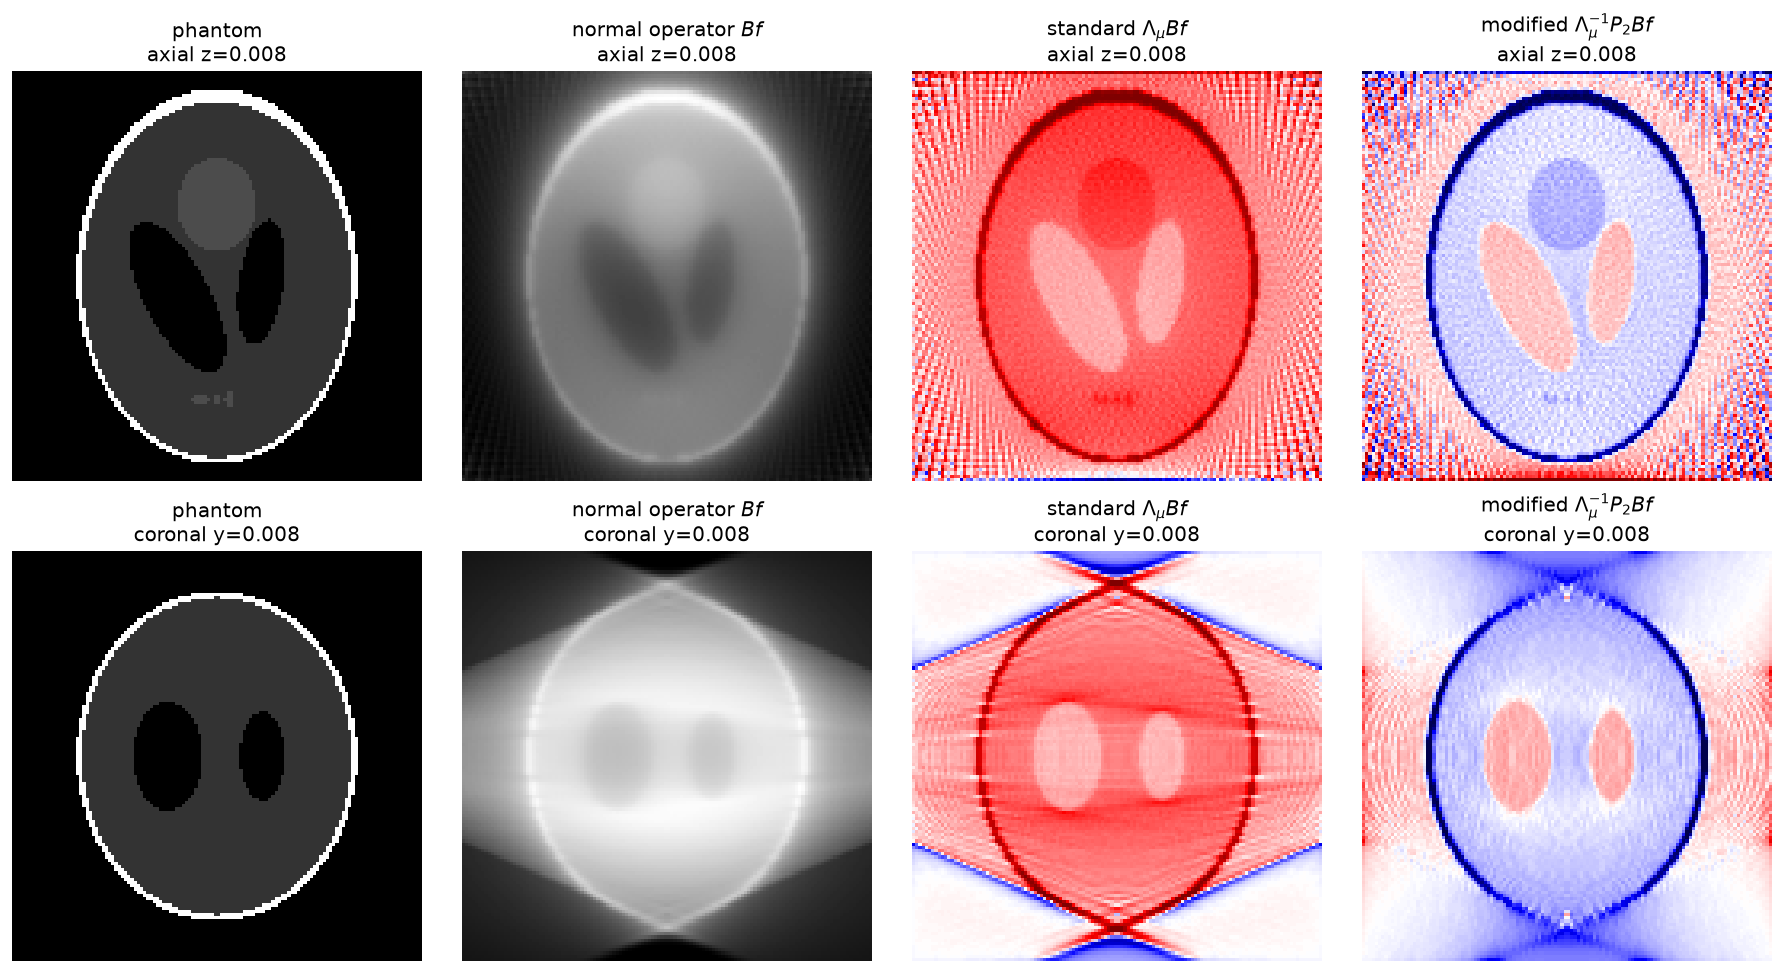

In [8]:
middle = phantom.shape[1] // 2
slice_coordinate = np.linspace(-1.0, 1.0, N)[middle]
planes = [
    (f"axial z={slice_coordinate:.3f}", lambda a: a[middle]),
    (f"coronal y={slice_coordinate:.3f}", lambda a: a[:, middle, :]),
]
columns = [
    ("phantom", phantom, "gray", False),
    (r"normal operator $Bf$", normal, "gray", False),
    (r"standard $\Lambda_\mu Bf$", standard, "seismic", True),
    (r"modified $\Lambda_\mu^{-1}P_2Bf$", artifact_reduced, "seismic", True),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)
for row, (plane_name, cut) in enumerate(planes):
    for col, (title, volume, cmap, signed) in enumerate(columns):
        image = cut(volume)
        if col > 0:
            image = robust_scale(image, 99.5)
        kwargs = {'vmin': -1, 'vmax': 1} if signed else {}
        axes[row, col].imshow(image, origin='lower', cmap=cmap, **kwargs)
        axes[row, col].set_title(f"{title}\n{plane_name}")
        axes[row, col].axis('off')
figure_dir = Path('figures')
figure_dir.mkdir(exist_ok=True)
fig.savefig(figure_dir / 'artifact_comparison.png', dpi=180)
plt.show()

Each non-phantom slice is scaled by its own 99.5th percentile of absolute intensity; signed panels use limits $[-1,1]$. The figure shows spatial structure rather than a common quantitative intensity scale. The coronal slices contain crossing streaks whose amplitude is reduced by the modified filter.

### Artifact diagnostic

For each coronal reconstruction, the normalization is the 95th percentile of absolute response on a dilated phantom-edge mask. Amplitude and Sobel-gradient RMS values are then measured outside a five-pixel dilation of the phantom support. These masks use the known synthetic ground truth.

In [9]:
middle = phantom.shape[1] // 2
phantom_slice = phantom[:, middle, :]
standard_slice = standard[:, middle, :]
reduced_slice = artifact_reduced[:, middle, :]

phantom_gradient = np.hypot(sobel(phantom_slice, axis=0), sobel(phantom_slice, axis=1))
true_edge_mask = binary_dilation(
    phantom_gradient > 0.05 * phantom_gradient.max(), iterations=2
)
outside_mask = ~binary_dilation(np.abs(phantom_slice) > 1e-5, iterations=5)

def artifact_metrics(image):
    # Normalization by the 95th-percentile response on the phantom-edge mask.
    edge_scale = np.percentile(np.abs(image[true_edge_mask]), 95)
    normalized = image / edge_scale
    outside_amplitude_rms = np.sqrt(np.mean(normalized[outside_mask] ** 2))
    grad = np.hypot(sobel(normalized, axis=0), sobel(normalized, axis=1))
    outside_gradient_rms = np.sqrt(np.mean(grad[outside_mask] ** 2))
    return outside_amplitude_rms, outside_gradient_rms

amp_standard, grad_standard = artifact_metrics(standard_slice)
amp_reduced, grad_reduced = artifact_metrics(reduced_slice)
metric_table = pd.DataFrame(
    {
        'outside amplitude RMS': [amp_standard, amp_reduced],
        'outside gradient RMS': [grad_standard, grad_reduced],
    },
    index=['standard elliptic', 'two-sheet reduced'],
)
print(metric_table.round(4))
print(
    f"Outside-gradient reduction after edge matching: "
    f"{100 * (1 - grad_reduced / grad_standard):.1f}%"
)

results = {
    'executed_at_utc': datetime.now(timezone.utc).isoformat(),
    'environment': {
        'python': platform.python_version(),
        'system': platform.system(),
        'machine': platform.machine(),
        'workers': WORKERS,
        'packages': {name: version(name) for name in
                     ['numpy', 'scipy', 'pandas', 'matplotlib', 'joblib', 'ipykernel']},
    },
    'parameters': {
        'N': N, 'views': N_ANGLES, 'source_radius': SOURCE_RADIUS,
        'detector_pixels': 2 * N, 'detector_half_width': 2.05,
        'samples_per_voxel': 1.0, 'low_frequency': float(np.pi),
        'smoothing_order': 1.0,
    },
    'check': {
        'N': n_check, 'views': angle_check,
        'relative_l2_discrepancy': float(relative_l2_error),
        'tolerance': 0.06,
    },
    'timings_seconds': timings,
    'metrics': {
        'standard': {'outside_amplitude_rms': float(amp_standard),
                     'outside_gradient_rms': float(grad_standard)},
        'modified': {'outside_amplitude_rms': float(amp_reduced),
                     'outside_gradient_rms': float(grad_reduced)},
        'outside_gradient_reduction_percent': float(100 * (1 - grad_reduced / grad_standard)),
    },
}
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)
(results_dir / 'demo_results.json').write_text(json.dumps(results, indent=2) + '\n')

                   outside amplitude RMS  outside gradient RMS
standard elliptic                 0.1817                0.7696
two-sheet reduced                 0.1466                0.2199
Outside-gradient reduction after edge matching: 71.4%


1245

The outside-gradient diagnostic measures this phantom and this discretization. It does not establish preservation of all object singularities or performance on measured scanner data.

## 10. Limitations and next steps

- The experiment computes local reconstructions from $R_C^*R_Cf$, rather than an FDK inversion or calibrated attenuation map.
- A circular trajectory has incomplete directional coverage. The effect of the filter near intersecting characteristic sheets and on true edges needs further study.
- Finite views, detector interpolation, and periodic FFT boundaries introduce additional numerical artifacts.
- Planned studies vary the voxel grid, source angles, detector sampling, and smoothing order, and report both artifact suppression and edge fidelity.
- The current implementation uses idealized geometry and synthetic noiseless data; calibrated geometry and noise experiments remain future work.

## References and source notes

David Finch, Ih-Ren Lan and Gunther Uhlmann, *Microlocal Analysis of the X-Ray Transform with Sources on a Curve*, in **Inside Out: Inverse Problems and Applications**, MSRI Publications 47 (2003), pp. 193–218. [Chapter PDF](https://library.slmath.org/books/Book47/files/uhlmann.pdf).

The MATLAB source archive `fwd.zip` is a development reference and is not required or distributed here. The Python implementation uses a detector-based normal operator, signed Fourier frequencies, and explicit elliptic smoothing. The phantom is adapted from Matthias Christian Schabel's `phantom3d.m` (2005); its original notice is preserved in [THIRD_PARTY_NOTICES.md](THIRD_PARTY_NOTICES.md).